In [1]:
import pandas as pd
import numpy as np

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("="*80)
print("DATA PREPROCESSING AND CLEANING PIPELINE")
print("="*80)
print("\nLibraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

DATA PREPROCESSING AND CLEANING PIPELINE

Libraries imported successfully.
Pandas version: 3.0.0
NumPy version: 2.3.5


In [2]:
print("DATA LOADING")
print("="*80)

data_path = r'C:\Users\ZEYNEP\house_price_prediction\data\kc_house_data.csv'
df = pd.read_csv(data_path)

print(f"\n Dataset loaded successfully")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

DATA LOADING

 Dataset loaded successfully
Shape: (21613, 21)
Columns: ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

First 5 rows:
           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000 221900.00         3       1.00         1180   
1  6414100192  20141209T000000 538000.00         3       2.25         2570   
2  5631500400  20150225T000000 180000.00         2       1.00          770   
3  2487200875  20141209T000000 604000.00         4       3.00         1960   
4  1954400510  20150218T000000 510000.00         3       2.00         1680   

   sqft_lot  floors  waterfront  view  condition  grade  sqft_above  \
0      5650    1.00           0     0          3      7        1180   
1      7242    2.00           0     0          3      7  

In [3]:
print("INITIAL DATA QUALITY CHECK")
print("="*80)

print("\nMissing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")

print("\nBasic Statistics:")
print(df.describe())

print("\n" + "-"*80)
print("ANOMALY CHECK (FROM EDA FINDINGS):")
print("-"*80)

#33 bedroom anomaly
bedroom_33 = df[df['bedrooms'] == 33]
print(f"\n1. Houses with 33 bedrooms: {len(bedroom_33)}")
if len(bedroom_33) > 0:
    print(bedroom_33[['bedrooms', 'bathrooms', 'sqft_living', 'price']].head())

#0 bathroom anomaly
bathroom_0 = df[df['bathrooms'] == 0]
print(f"\n2. Houses with 0 bathrooms: {len(bathroom_0)}")
if len(bathroom_0) > 0:
    print(bathroom_0[['bedrooms', 'bathrooms', 'sqft_living', 'price']].head())

#0 bedroom (studios - legitimate)
bedroom_0 = df[df['bedrooms'] == 0]
print(f"\n3. Houses with 0 bedrooms (studios): {len(bedroom_0)}")
print(" -> These are legitimate studio apartments (KEEP)")

print("\n" + "="*80)
print(f"Initial dataset shape: {df.shape}")
print("="*80)

INITIAL DATA QUALITY CHECK

Missing Values:
No missing values

Duplicate Rows: 0

Basic Statistics:
                 id      price  bedrooms  bathrooms  sqft_living   sqft_lot  \
count      21613.00   21613.00  21613.00   21613.00     21613.00   21613.00   
mean  4580301520.86  540088.14      3.37       2.11      2079.90   15106.97   
std   2876565571.31  367127.20      0.93       0.77       918.44   41420.51   
min      1000102.00   75000.00      0.00       0.00       290.00     520.00   
25%   2123049194.00  321950.00      3.00       1.75      1427.00    5040.00   
50%   3904930410.00  450000.00      3.00       2.25      1910.00    7618.00   
75%   7308900445.00  645000.00      4.00       2.50      2550.00   10688.00   
max   9900000190.00 7700000.00     33.00       8.00     13540.00 1651359.00   

        floors  waterfront     view  condition    grade  sqft_above  \
count 21613.00    21613.00 21613.00   21613.00 21613.00    21613.00   
mean      1.49        0.01     0.23       3.41

In [4]:
print("FIX ANOMALIES")
print("="*80)

df_clean = df.copy()

print("\nAnomalies to fix:")
print("-"*80)

#33 bedrooms
print("\n1. FIXING 33 BEDROOM ANOMALY:")
print(f" Before: {len(df_clean[df_clean['bedrooms'] == 33])} house(s) with 33 bedrooms")

df_clean = df_clean[df_clean['bedrooms'] != 33]

print(f" After: {len(df_clean[df_clean['bedrooms'] == 33])} house(s) with 33 bedrooms")
print(f" REMOVED 1 anomalous record")

#0 bathrooms
print("\n2. FIXING 0 BATHROOM ANOMALY:")
before_count = len(df_clean[df_clean['bathrooms'] == 0])
print(f" Before: {before_count} houses with 0 bathrooms")

df_clean = df_clean[df_clean['bathrooms'] > 0]

after_count = len(df_clean[df_clean['bathrooms'] == 0])
print(f" After: {after_count} house(s) with 0 bathrooms ")
print(f" REMOVED {before_count} anomalous records")

#keep 0 bedrooms (studios)
print("\n3. KEEPING 0 BEDROOM HOUSES (STUDIOS):")
studios = df_clean[df_clean['bedrooms'] == 0]
print(f" Count: {len(studios)} studio apartments")
print(f" KEPT (legitimate)")

#summary
print("\n" + "="*80)
print("CLEANING SUMMARY:")
print("="*80)
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print(f"Records removed: {df.shape[0] - df_clean.shape[0]}")
print(f"Removal rate: {((df.shape[0] - df_clean.shape[0]) / df.shape[0] * 100):.2f}%")
print("="*80)

print("\nVERIFICATION:")
print(f" Max bedrooms: {df_clean['bedrooms'].max()}")
print(f" Min bathrooms: {df_clean['bathrooms'].min()}")
print(f" Studios (0 bedrooms): {len(df_clean[df_clean['bedrooms'] == 0])}")

FIX ANOMALIES

Anomalies to fix:
--------------------------------------------------------------------------------

1. FIXING 33 BEDROOM ANOMALY:
 Before: 1 house(s) with 33 bedrooms
 After: 0 house(s) with 33 bedrooms
 REMOVED 1 anomalous record

2. FIXING 0 BATHROOM ANOMALY:
 Before: 10 houses with 0 bathrooms
 After: 0 house(s) with 0 bathrooms 
 REMOVED 10 anomalous records

3. KEEPING 0 BEDROOM HOUSES (STUDIOS):
 Count: 6 studio apartments
 KEPT (legitimate)

CLEANING SUMMARY:
Original shape: (21613, 21)
Cleaned shape: (21602, 21)
Records removed: 11
Removal rate: 0.05%

VERIFICATION:
 Max bedrooms: 11
 Min bathrooms: 0.5
 Studios (0 bedrooms): 6



OUTLIER ANALYSIS

Price Outlier Analysis (IQR Method):
Q1 (25th percentile): $322,000.00
Q3 (75th percentile): $645,000.00
IQR: $323,000.00
Outlier threshold (Q3 + 1.5*IQR): $1,129,500.00

Number of price outliers: 1145 (5.30%)
Price range of outliers: $1,130,000.00 - $7,700,000.00


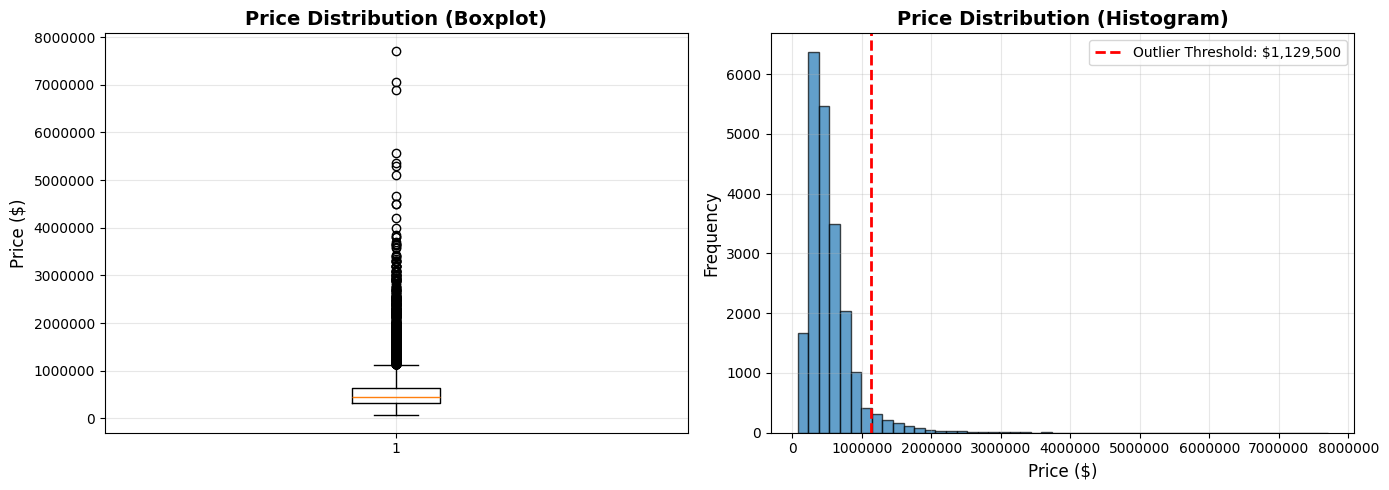


--------------------------------------------------------------------------------
DECISION: KEEP OUTLIERS
--------------------------------------------------------------------------------
Reason: These are legitimate high-value houses (luxury homes, waterfront)

All outliers retained
Final cleaned dataset shape: (21602, 21)


In [5]:
print("\n" + "="*80)
print("OUTLIER ANALYSIS")
print("="*80)

# Calculate outlier threshold using IQR method (from EDA)
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR

print(f"\nPrice Outlier Analysis (IQR Method):")
print(f"Q1 (25th percentile): ${Q1:,.2f}")
print(f"Q3 (75th percentile): ${Q3:,.2f}")
print(f"IQR: ${IQR:,.2f}")
print(f"Outlier threshold (Q3 + 1.5*IQR): ${outlier_threshold:,.2f}")

#count outliers
outliers = df_clean[df_clean['price'] > outlier_threshold]
print(f"\nNumber of price outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}%)")
print(f"Price range of outliers: ${outliers['price'].min():,.2f} - ${outliers['price'].max():,.2f}")

fig, axes = plt.subplots(1, 2,figsize=(14, 5))

axes[0].boxplot(df_clean['price'], vert=True)
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].set_title('Price Distribution (Boxplot)', fontsize=14, fontweight='bold')
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].grid(alpha=0.3)

axes[1].hist(df_clean['price'], bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(outlier_threshold, color='red', linestyle='--', linewidth=2, label=f'Outlier Threshold: ${outlier_threshold:,.0f}')
axes[1].set_xlabel('Price ($)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Price Distribution (Histogram)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].ticklabel_format(style='plain', axis='x')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "-"*80)
print("DECISION: KEEP OUTLIERS")
print("-"*80)
print("Reason: These are legitimate high-value houses (luxury homes, waterfront)")
print("\nAll outliers retained")
print(f"Final cleaned dataset shape: {df_clean.shape}")

In [6]:
print("DATA TYPE CONVERSIONS")
print("="*80)

print("\nCurrent data types:")
print(df_clean.dtypes)

df_clean['id'] = df_clean['id'].astype(str)
print("\nConverted 'id' to string")

df_clean['date'] = pd.to_datetime(df_clean['date'])
print("Converted 'date' to datetime")

print("\nUpdated data types:")
print(df_clean[['id', 'date']].dtypes)

print("\nSample of converted columns:")
print(df_clean[['id', 'date']].head())

print(f"\nDataset shape: {df_clean.shape}")

DATA TYPE CONVERSIONS

Current data types:
id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

Converted 'id' to string
Converted 'date' to datetime

Updated data types:
id                 str
date    datetime64[us]
dtype: object

Sample of converted columns:
           id       date
0  7129300520 2014-10-13
1  6414100192 2014-12-09
2  5631500400 2015-02-25
3  2487200875 2014-12-09
4  1954400510 2015-02-18

Dataset shape: (21602, 21)


In [7]:
print("FINAL VALIDATION")
print("="*80)

print("\n1. DATA QUALITY VERIFICATION:")
print("-" * 80)

# Re-verify no issues were introduced during preprocessing
missing_count = df_clean.isnull().sum().sum()
duplicate_count = df_clean.duplicated().sum()

print(f"Missing values: {missing_count}")
print(f"Duplicate rows: {duplicate_count}")

print(f"\n2. DATA TYPE VERIFICATION:")
print("-" * 80)
print(f"'id' is string: {df_clean['id'].dtype == 'str' or df_clean['id'].dtype == 'object'}")
print(f"'date' is datetime: {pd.api.types.is_datetime64_any_dtype(df_clean['date'])}")

print(f"\n3. DATA RANGE CHECKS:")
print("-" * 80)
print(f"Bedrooms: min={df_clean['bedrooms'].min()}, max={df_clean['bedrooms'].max()}")
print(f"Bathrooms: min={df_clean['bathrooms'].min():.1f}, max={df_clean['bathrooms'].max():.1f}")
print(f" Price: min=${df_clean['price'].min():,.2f}, max=${df_clean['price'].max():,.2f}")

print(f"\n4. DATE RANGE:")
print("-" * 80)
print(f"Earliest sale: {df_clean['date'].min()}")
print(f"Latest sale: {df_clean['date'].max()}")
print(f"Time span: {(df_clean['date'].max() - df_clean['date'].min()).days} days")

print(f"\n5. FINAL DATASET SUMMARY:")
print("=" * 80)
print(f"Total rows: {df_clean.shape[0]}")
print(f"Total columns: {df_clean.shape[1]}")
print(f"Memory usage: {df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "="*80)
print("ALL VALIDATION CHECKS PASSED")
print("="*80)

FINAL VALIDATION

1. DATA QUALITY VERIFICATION:
--------------------------------------------------------------------------------
Missing values: 0
Duplicate rows: 0

2. DATA TYPE VERIFICATION:
--------------------------------------------------------------------------------
'id' is string: True
'date' is datetime: True

3. DATA RANGE CHECKS:
--------------------------------------------------------------------------------
Bedrooms: min=0, max=11
Bathrooms: min=0.5, max=8.0
 Price: min=$78,000.00, max=$7,700,000.00

4. DATE RANGE:
--------------------------------------------------------------------------------
Earliest sale: 2014-05-02 00:00:00
Latest sale: 2015-05-27 00:00:00
Time span: 390 days

5. FINAL DATASET SUMMARY:
Total rows: 21602
Total columns: 21
Memory usage: 4.84 MB

ALL VALIDATION CHECKS PASSED


In [8]:
print("SAVE CLEANED DATA")
print("="*80)

output_path = 'data/cleaned_kc_house_data.csv'

df_clean.to_csv(output_path, index=False)

print(f"\nCleaned dataset saved successfully")
print(f"Location: {output_path}")
print(f"Shape: {df_clean.shape}")

# Verify file was created
import os
if os.path.exists(output_path):
    file_size = os.path.getsize(output_path) / 1024**2  # Convert to MB
    print(f"File size: {file_size:.2f} MB")
    print("File verification: SUCCESS")
else:
    print("Warning: File not found")

print("\n" + "="*80)
print("DATA PREPROCESSING PIPELINE COMPLETE")
print("="*80)

print("\nPREPROCESSING SUMMARY:")
print("-" * 80)
print(f"  Original dataset: 21,613 rows × 21 columns")
print(f"  Removed anomalies: 11 rows")
print(f"   - 1 house with 33 bedrooms")
print(f"   - 10 houses with 0 bathrooms")
print(f"  Data type conversions: 2 columns (id, date)")
print(f"  Outliers kept: 1,145 luxury homes (5.30%)")
print(f"  Final dataset: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"  Data quality: 0 missing, 0 duplicates")

SAVE CLEANED DATA

Cleaned dataset saved successfully
Location: data/cleaned_kc_house_data.csv
Shape: (21602, 21)
File size: 2.24 MB
File verification: SUCCESS

DATA PREPROCESSING PIPELINE COMPLETE

PREPROCESSING SUMMARY:
--------------------------------------------------------------------------------
  Original dataset: 21,613 rows × 21 columns
  Removed anomalies: 11 rows
   - 1 house with 33 bedrooms
   - 10 houses with 0 bathrooms
  Data type conversions: 2 columns (id, date)
  Outliers kept: 1,145 luxury homes (5.30%)
  Final dataset: 21602 rows × 21 columns
  Data quality: 0 missing, 0 duplicates
